# AML23703 – Quantum Computing

# Tutorial 3: Single-Qubit Quantum Gates

### Name: LAASYA S D

### USN: 1GA23AI021

### Department: Artificial Intelligence and Machine Learning

### Semester: VII

### Course Code: AML23703

### Date: 06-08-2026

# Objective

The objective of this tutorial is to understand the working of single-qubit quantum gates such as Pauli-X, Pauli-Y, Pauli-Z and Hadamard gates. It also aims to study how these gates transform qubit states, visualize the changes using Qiskit, and apply them to simple quantum computing applications.

# Theory

A qubit is the basic unit of quantum information. Unlike a classical bit, a qubit can exist in a superposition of states. Single-qubit quantum gates are unitary operations that change the state of a qubit.

- **Pauli-X Gate:** Flips |0⟩ to |1⟩ and vice versa.
- **Pauli-Y Gate:** Flips the qubit and introduces a phase of *i*.
- **Pauli-Z Gate:** Changes only the phase of the |1⟩ state.
- **Hadamard (H) Gate:** Creates a superposition state.

These gates form the building blocks of quantum algorithms.

# Exercise 1 (Easy)

## Question

Create a qubit in state |0⟩, apply the X, Y and Z gates individually on separate qubits and print/visualize the resulting statevectors.

Statevector after X Gate:
Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


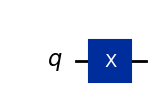

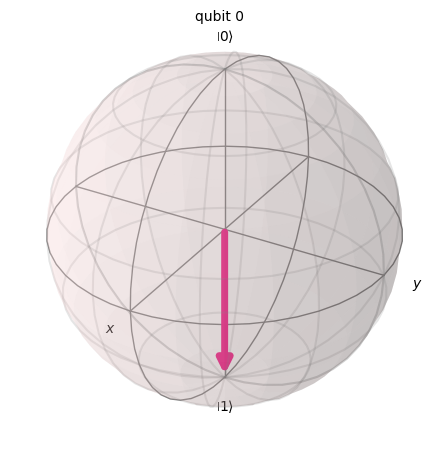


Statevector after Y Gate:
Statevector([0.+0.j, 0.+1.j],
            dims=(2,))


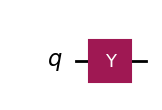

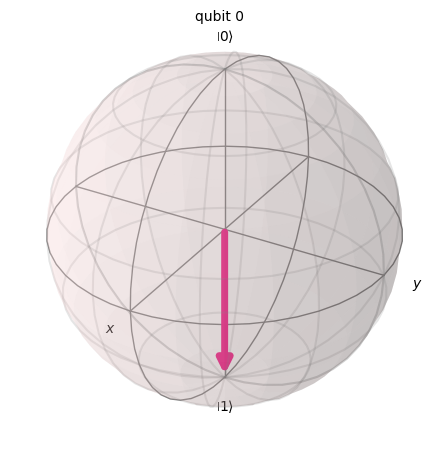


Statevector after Z Gate:
Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


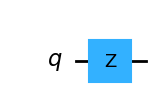

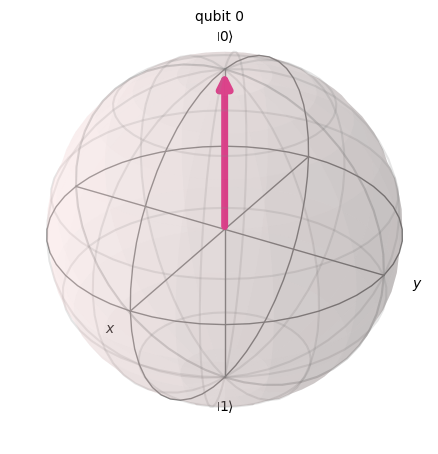

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from IPython.display import display

# ---------------- X Gate ----------------
qc_x = QuantumCircuit(1)
qc_x.x(0)

state_x = Statevector.from_instruction(qc_x)

print("Statevector after X Gate:")
print(state_x)

display(qc_x.draw("mpl"))
display(plot_bloch_multivector(state_x))


# ---------------- Y Gate ----------------
qc_y = QuantumCircuit(1)
qc_y.y(0)

state_y = Statevector.from_instruction(qc_y)

print("\nStatevector after Y Gate:")
print(state_y)

display(qc_y.draw("mpl"))
display(plot_bloch_multivector(state_y))


# ---------------- Z Gate ----------------
qc_z = QuantumCircuit(1)
qc_z.z(0)

state_z = Statevector.from_instruction(qc_z)

print("\nStatevector after Z Gate:")
print(state_z)

display(qc_z.draw("mpl"))
display(plot_bloch_multivector(state_z))

## Observation

The Pauli-X gate changed the qubit from |0⟩ to |1⟩. The Pauli-Y gate also changed the qubit state while introducing a phase factor. The Pauli-Z gate changed only the phase of the qubit and did not change the measured state when starting from |0⟩. The statevectors and Bloch sphere visualizations clearly show the effect of each quantum gate.

## Conclusion

The X, Y and Z quantum gates were successfully implemented. The resulting statevectors and Bloch sphere visualizations verified the unique operation performed by each gate on the qubit. This experiment demonstrates the basic behaviour of single-qubit quantum gates.

# Exercise 2 (Medium)

## Question

Combine the Hadamard (H) gate and Pauli-Z gate to construct the |−⟩ state and verify it experimentally through simulation.

Statevector:
Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))


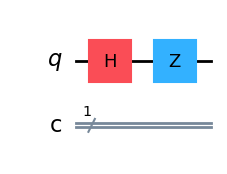

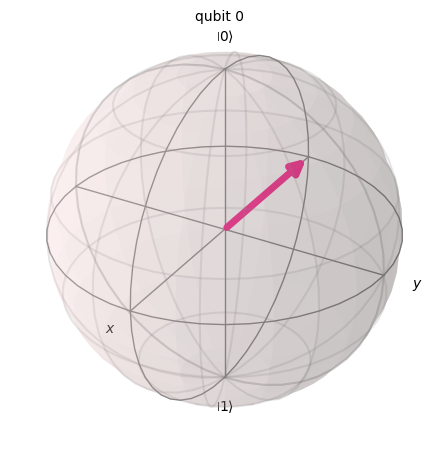


Measurement Counts:
{'0': 548, '1': 476}


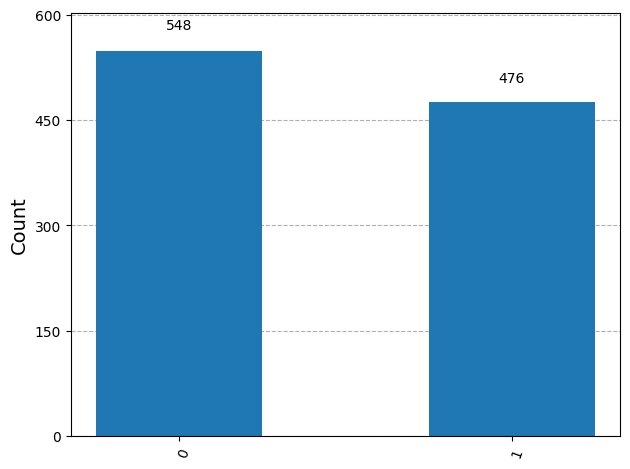

In [2]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit_aer import AerSimulator
from qiskit import transpile
from IPython.display import display

# Create a quantum circuit with 1 qubit and 1 classical bit
qc = QuantumCircuit(1, 1)

# Apply Hadamard gate
qc.h(0)

# Apply Z gate to create |->
qc.z(0)

# Save statevector before measurement
state = Statevector.from_instruction(qc.remove_final_measurements(inplace=False))

print("Statevector:")
print(state)

# Display circuit
display(qc.draw("mpl"))

# Display Bloch Sphere
display(plot_bloch_multivector(state))

# Measure the qubit
qc.measure(0, 0)

# Run simulation
simulator = AerSimulator()
compiled = transpile(qc, simulator)
job = simulator.run(compiled, shots=1024)
result = job.result()

counts = result.get_counts()

print("\nMeasurement Counts:")
print(counts)

# Display histogram
display(plot_histogram(counts))

## Observation

The Hadamard gate first created an equal superposition of |0⟩ and |1⟩. The Pauli-Z gate then changed the phase of the |1⟩ component, producing the |−⟩ state. The Bloch Sphere showed the new orientation of the qubit, while the simulator verified the circuit through measurement.

## Conclusion

The |−⟩ state was successfully created using the Hadamard and Pauli-Z gates. The statevector, Bloch Sphere visualization and simulation results confirmed the correct implementation of the quantum circuit.

# Exercise 3 (Hard)

## Question

Build a circuit that applies a sequence of five single-qubit gates and determine the final quantum state analytically, then verify it using simulation.

Final Statevector:
Statevector([-0.70710678+0.j        ,  0.        +0.70710678j],
            dims=(2,))


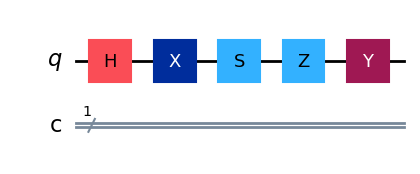

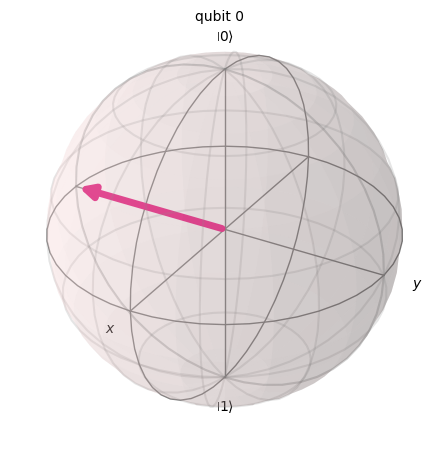


Measurement Counts:
{'1': 520, '0': 504}


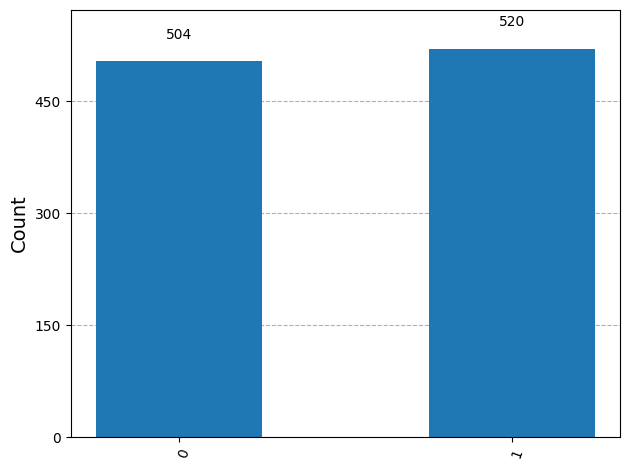

In [3]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit_aer import AerSimulator
from IPython.display import display

# Create a quantum circuit
qc = QuantumCircuit(1, 1)

# Apply five single-qubit gates
qc.h(0)
qc.x(0)
qc.s(0)
qc.z(0)
qc.y(0)

# Generate statevector before measurement
state = Statevector.from_instruction(qc.remove_final_measurements(inplace=False))

print("Final Statevector:")
print(state)

# Display circuit
display(qc.draw("mpl"))

# Display Bloch Sphere
display(plot_bloch_multivector(state))

# Measure the qubit
qc.measure(0, 0)

# Run simulator
simulator = AerSimulator()

compiled = transpile(qc, simulator)

job = simulator.run(compiled, shots=1024)

result = job.result()

counts = result.get_counts()

print("\nMeasurement Counts:")
print(counts)

display(plot_histogram(counts))

## Observation

The circuit applies the gates in the sequence **H → X → S → Z → Y**. Each gate changes the quantum state by either rotating the qubit, flipping its value, or changing its phase. The final statevector represents the analytical result of applying all five gates in sequence. The simulator produces measurement results that verify the final quantum state.

## Conclusion

A sequence of five single-qubit gates was successfully applied to a qubit. The final statevector and Bloch Sphere visualization matched the simulated quantum state, confirming the correctness of the circuit implementation.

# Exercise 4 (Real-World Application)

## Question

Use single-qubit gates to model a simple quantum coin-flip game and calculate the probabilities of getting Heads and Tails.

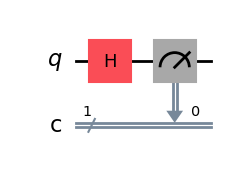

Measurement Counts:
{'0': 517, '1': 483}

Probability of Heads : 0.517
Probability of Tails : 0.483


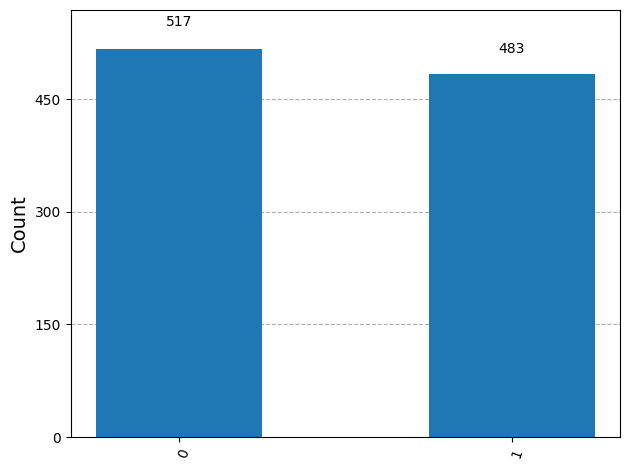

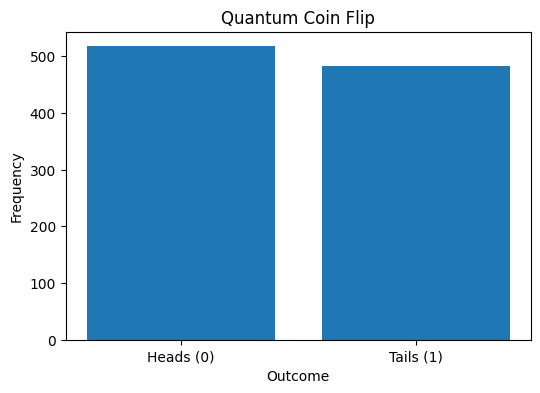

In [4]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display
import matplotlib.pyplot as plt

# Create a quantum circuit
qc = QuantumCircuit(1, 1)

# Apply Hadamard gate to create a fair quantum coin
qc.h(0)

# Measure the qubit
qc.measure(0, 0)

# Display the circuit
display(qc.draw("mpl"))

# Run the simulator
simulator = AerSimulator()

compiled = transpile(qc, simulator)

job = simulator.run(compiled, shots=1000)

result = job.result()

counts = result.get_counts()

print("Measurement Counts:")
print(counts)

# Calculate probabilities
heads = counts.get('0', 0)
tails = counts.get('1', 0)

total = heads + tails

print("\nProbability of Heads :", heads / total)
print("Probability of Tails :", tails / total)

# Histogram
display(plot_histogram(counts))

# Bar Graph
labels = ["Heads (0)", "Tails (1)"]
values = [heads, tails]

plt.figure(figsize=(6,4))
plt.bar(labels, values)

plt.title("Quantum Coin Flip")
plt.xlabel("Outcome")
plt.ylabel("Frequency")

plt.show()

## Observation

A Hadamard gate was used to create a quantum superposition, allowing the qubit to behave like a fair coin. After measuring the qubit 1000 times, the number of Heads (0) and Tails (1) was nearly equal. The histogram and bar graph confirmed that both outcomes occurred with approximately equal probability.

## Conclusion

A simple quantum coin-flip game was successfully implemented using a single qubit and the Hadamard gate. The simulation produced nearly equal probabilities for Heads and Tails, demonstrating how quantum superposition can be used to generate random outcomes.

# Reflection Questions

### 1. Which gate combination surprised you the most in producing an equivalent transformation?

The combination of the Hadamard and Pauli-Z gates was the most surprising because they together created the |−⟩ state. It showed that combining simple quantum gates can produce new quantum states and change the phase of a qubit without affecting the measurement probabilities.

---

### 2. How would you explain the physical meaning of the Hadamard gate to a classical programmer?

The Hadamard gate is like flipping a perfectly balanced coin. Instead of changing a qubit to only 0 or 1, it places the qubit into a superposition where it has an equal probability of being measured as 0 or 1. This ability to exist in multiple states at once is one of the key differences between quantum and classical computing.

# Exercise 5 (Challenge)

## Question

Prove that the gate combination HZH (Hadamard–Z–Hadamard) is equivalent to the Pauli-X gate, both analytically and using circuit simulation.

Statevector of HZH:
Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


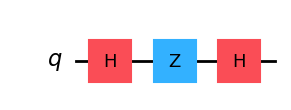

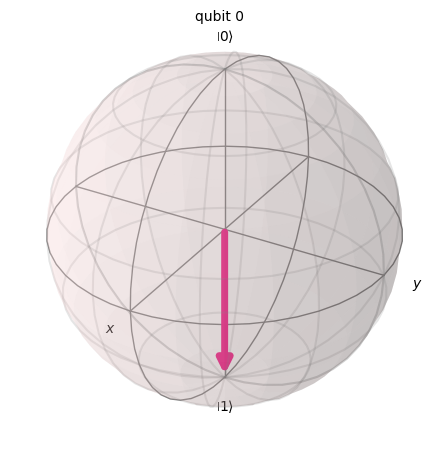


Statevector of X Gate:
Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


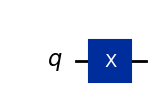

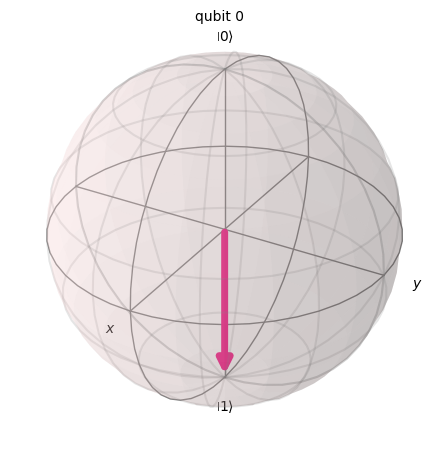


Are both statevectors equal?
True


In [5]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from IPython.display import display

# Circuit 1: HZH
qc1 = QuantumCircuit(1)
qc1.h(0)
qc1.z(0)
qc1.h(0)

state1 = Statevector.from_instruction(qc1)

print("Statevector of HZH:")
print(state1)

display(qc1.draw("mpl"))
display(plot_bloch_multivector(state1))


# Circuit 2: X Gate
qc2 = QuantumCircuit(1)
qc2.x(0)

state2 = Statevector.from_instruction(qc2)

print("\nStatevector of X Gate:")
print(state2)

display(qc2.draw("mpl"))
display(plot_bloch_multivector(state2))


# Verify equivalence
print("\nAre both statevectors equal?")
print(state1.equiv(state2))

## Analytical Proof

The gate identity is:

HZH = X

Applying the Hadamard gate before and after the Pauli-Z gate changes the basis of the qubit. This transformation converts the phase-flip operation (Z gate) into a bit-flip operation (X gate). Therefore, the sequence HZH performs exactly the same operation as the Pauli-X gate.

## Observation

The statevector obtained after applying the HZH sequence was identical to the statevector produced by the Pauli-X gate. The Bloch Sphere visualizations also matched, confirming that both circuits perform the same quantum operation.

## Conclusion

The experiment successfully verified that the gate sequence HZH is equivalent to the Pauli-X gate. Both the analytical explanation and the circuit simulation produced identical results, confirming the gate equivalence.